# Synthetic Data Generation Using RAGAS - RAG Evaluation with LangSmith

In the following notebook we'll explore a use-case for RAGAS' synthetic testset generation workflow!



- 🤝 BREAKOUT ROOM #1
  1. Use RAGAS to Generate Synthetic Data

- 🤝 BREAKOUT ROOM #2
  1. Load them into a LangSmith Dataset
  2. Evaluate our RAG chain against the synthetic test data
  3. Make changes to our pipeline
  4. Evaluate the modified pipeline

SDG is a critical piece of the puzzle, especially for early iteration! Without it, it would not be nearly as easy to get high quality early signal for our application's performance.

Let's dive in!

# 🤝 BREAKOUT ROOM #1

## Task 1: Dependencies and API Keys

We'll need to install a number of API keys and dependencies, since we'll be leveraging a number of great technologies for this pipeline!

1. OpenAI's endpoints to handle the Synthetic Data Generation
2. OpenAI's Endpoints for our RAG pipeline and LangSmith evaluation
3. QDrant as our vectorstore
4. LangSmith for our evaluation coordinator!

Let's install and provide all the required information below!

## Dependencies and API Keys:

### NLTK Import

To prevent errors that may occur based on OS - we'll import NLTK and download the needed packages to ensure correct handling of data.

In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ashimamangla/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ashimamangla/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [2]:
import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

We'll also want to set a project name to make things easier for ourselves.

In [3]:
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - {uuid4().hex[0:8]}"

OpenAI's API Key!

In [4]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - which should hopefull be familiar at this point since it's our Use-Case Data!

Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [5]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Unrolled SDG

In [6]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

Next, we're going to instantiate our Knowledge Graph.

This graph will contain N number of nodes that have M number of relationships. These nodes and relationships (AKA "edges") will define our knowledge graph and be used later to construct relevant questions and responses.

In [7]:
from ragas.testset.graph import KnowledgeGraph

kg = KnowledgeGraph()
kg

KnowledgeGraph(nodes: 0, relationships: 0)

The first step we're going to take is to simply insert each of our full documents into the graph. This will provide a base that we can apply transformations to.

In [8]:
from ragas.testset.graph import Node, NodeType

### NOTICE: We're using a subset of the data for this example - this is to keep costs/time down.
for doc in docs:
    kg.nodes.append(
        Node(
            type=NodeType.DOCUMENT,
            properties={"page_content": doc.page_content, "document_metadata": doc.metadata}
        )
    )
kg

KnowledgeGraph(nodes: 64, relationships: 0)

Now, we'll apply the *default* transformations to our knowledge graph. This will take the nodes currently on the graph and transform them based on a set of [default transformations](https://docs.ragas.io/en/latest/references/transforms/#ragas.testset.transforms.default_transforms).

These default transformations are dependent on the corpus length, in our case:

- Producing Summaries -> produces summaries of the documents
- Extracting Headlines -> finding the overall headline for the document
- Theme Extractor -> extracts broad themes about the documents

It then uses cosine-similarity and heuristics between the embeddings of the above transformations to construct relationships between the nodes.

In [9]:
from ragas.testset.transforms import default_transforms, apply_transforms

transformer_llm = generator_llm
embedding_model = generator_embeddings

default_transforms = default_transforms(documents=docs, llm=transformer_llm, embedding_model=embedding_model)
apply_transforms(kg, default_transforms)
kg

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to ap

Applying SummaryExtractor:   0%|          | 0/38 [00:00<?, ?it/s]

Property 'summary' already exists in node '32a351'. Skipping!
Property 'summary' already exists in node 'fde004'. Skipping!
Property 'summary' already exists in node 'a56c7c'. Skipping!
Property 'summary' already exists in node '4093d6'. Skipping!
Property 'summary' already exists in node '5c14d2'. Skipping!
Property 'summary' already exists in node '8c0555'. Skipping!
Property 'summary' already exists in node '6dfcda'. Skipping!
Property 'summary' already exists in node '12ecb4'. Skipping!
Property 'summary' already exists in node '46f589'. Skipping!
Property 'summary' already exists in node '3a9e7c'. Skipping!
Property 'summary' already exists in node '64545b'. Skipping!
Property 'summary' already exists in node '8fb41a'. Skipping!
Property 'summary' already exists in node '85eaae'. Skipping!
Property 'summary' already exists in node 'e21e0f'. Skipping!
Property 'summary' already exists in node '6e462f'. Skipping!
Property 'summary' already exists in node 'b9c8ce'. Skipping!
Property

Applying CustomNodeFilter:   0%|          | 0/8 [00:00<?, ?it/s]

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/48 [00:00<?, ?it/s]

Property 'summary_embedding' already exists in node '12ecb4'. Skipping!
Property 'summary_embedding' already exists in node '32a351'. Skipping!
Property 'summary_embedding' already exists in node 'a56c7c'. Skipping!
Property 'summary_embedding' already exists in node '8c0555'. Skipping!
Property 'summary_embedding' already exists in node 'e21e0f'. Skipping!
Property 'summary_embedding' already exists in node 'fde004'. Skipping!
Property 'summary_embedding' already exists in node '3a9e7c'. Skipping!
Property 'summary_embedding' already exists in node '6dfcda'. Skipping!
Property 'summary_embedding' already exists in node '4093d6'. Skipping!
Property 'summary_embedding' already exists in node '46f589'. Skipping!
Property 'summary_embedding' already exists in node '5c14d2'. Skipping!
Property 'summary_embedding' already exists in node '64545b'. Skipping!
Property 'summary_embedding' already exists in node '8fb41a'. Skipping!
Property 'summary_embedding' already exists in node '85eaae'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

KnowledgeGraph(nodes: 86, relationships: 711)

We can save and load our knowledge graphs as follows.

In [10]:
kg.save("usecase_data_kg.json")
usecase_data_kg = KnowledgeGraph.load("usecase_data_kg.json")
usecase_data_kg

KnowledgeGraph(nodes: 86, relationships: 711)

Using our knowledge graph, we can construct a "test set generator" - which will allow us to create queries.

In [11]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=embedding_model, knowledge_graph=usecase_data_kg)

However, we'd like to be able to define the kinds of queries we're generating - which is made simple by Ragas having pre-created a number of different "QuerySynthesizer"s.

Each of these Synthetsizers is going to tackle a separate kind of query which will be generated from a scenario and a persona.

In essence, Ragas will use an LLM to generate a persona of someone who would interact with the data - and then use a scenario to construct a question from that data and persona.

In [12]:
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer

query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.5),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]

#### ❓ Question #1:

What are the three types of query synthesizers doing? Describe each one in simple terms.


##### ✅ Answer:
SingleHopSpecificQuerySynthesizer: Creates factual questions that can be answered in one-hop requiring only one lookup from the information provided to find the answer . The 0.5 means that this will be half the number of queries generated will be single hop kind so this represents the distribution weight of the number of queries of this kind among all queries generated.

MultiHopAbstractQuerySynthesizer: This synthesizer will produce queries requiring multi-step reasoning to answer. It prompts the RAG system to find info across multiple documents or sections to generate a response. 
The ideas is to test the system's ability to reason from information from different parts of the knowledge base. 0.25 means that a fourth of the queries will be generated by this method

MultiHopSpecificQuerySynthesizer: This synthesizer is similar to the MultiHopAbstract synthesizer but focusses on creating questions that link concrete facts across documents. The purpose is to evaluate the system's ability to retrieve information about a specific subject from a document and connect it to information about the same subject in another document.  So the main difference between thte two multihop synthesizers are 'abstract' and 'concrete'


Finally, we can use our `TestSetGenerator` to generate our testset!

In [13]:
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,"What does Kulveit et al., 2025, contribute to ...",[Introduction ChatGPT launched in November 202...,"Kulveit et al., 2025, study the effects of art...",single_hop_specifc_query_synthesizer
1,What does the US refer to in the context of Ch...,[Table 1: ChatGPT daily message counts (millio...,"In the context of ChatGPT message usage, the U...",single_hop_specifc_query_synthesizer
2,What is Appendix D in the context of ChatGPT u...,[Variation by Occupation Figure 23 presents va...,Appendix D contains a full report of GWA count...,single_hop_specifc_query_synthesizer
3,How does the concept of management relate to t...,[Conclusion This paper studies the rapid growt...,The context discusses the rapid growth of Chat...,single_hop_specifc_query_synthesizer
4,how ChatGPT launch and rapid growth made it so...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,ChatGPT launched in November 2022 and by July ...,multi_hop_abstract_query_synthesizer
5,Considering the variation in ChatGPT usage by ...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,The data indicates that users in highly paid p...,multi_hop_abstract_query_synthesizer
6,How do Large Language Models (LLMs) like ChatG...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,"ChatGPT, launched in November 2022 and based o...",multi_hop_abstract_query_synthesizer
7,how november 2022 launch of ChatGPT and novemb...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,"ChatGPT launched in november 2022, and by july...",multi_hop_specific_query_synthesizer
8,Based on the rapid growth of ChatGPT to over 7...,[<1-hop>\n\nIntroduction ChatGPT launched in N...,"The widespread adoption of ChatGPT, with over ...",multi_hop_specific_query_synthesizer
9,How does the growth of ChatGPT usage in the US...,[<1-hop>\n\nTable 1: ChatGPT daily message cou...,"The context indicates that in the US, ChatGPT'...",multi_hop_specific_query_synthesizer


### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [25]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to ap

Applying SummaryExtractor:   0%|          | 0/39 [00:00<?, ?it/s]

Property 'summary' already exists in node 'ba6a76'. Skipping!
Property 'summary' already exists in node 'ecb6c6'. Skipping!
Property 'summary' already exists in node 'ae1174'. Skipping!
Property 'summary' already exists in node '2d0a82'. Skipping!
Property 'summary' already exists in node 'f0c0fa'. Skipping!
Property 'summary' already exists in node '3b949f'. Skipping!
Property 'summary' already exists in node '221b4d'. Skipping!
Property 'summary' already exists in node 'd806a9'. Skipping!
Property 'summary' already exists in node '60d298'. Skipping!
Property 'summary' already exists in node '8bfc65'. Skipping!
Property 'summary' already exists in node '0c454a'. Skipping!
Property 'summary' already exists in node '7e62fe'. Skipping!
Property 'summary' already exists in node 'e84235'. Skipping!
Property 'summary' already exists in node '9dd36d'. Skipping!
Property 'summary' already exists in node 'e578e4'. Skipping!
Property 'summary' already exists in node 'fe6c35'. Skipping!
Property

...

Property 'summary_embedding' already exists in node 'ae1174'. Skipping!
Property 'summary_embedding' already exists in node '221b4d'. Skipping!
Property 'summary_embedding' already exists in node 'ecb6c6'. Skipping!
Property 'summary_embedding' already exists in node '2d0a82'. Skipping!
Property 'summary_embedding' already exists in node 'f0c0fa'. Skipping!
Property 'summary_embedding' already exists in node 'ba6a76'. Skipping!
Property 'summary_embedding' already exists in node 'd806a9'. Skipping!
Property 'summary_embedding' already exists in node '3b949f'. Skipping!
Property 'summary_embedding' already exists in node 'e84235'. Skipping!
Property 'summary_embedding' already exists in node '60d298'. Skipping!
Property 'summary_embedding' already exists in node '9dd36d'. Skipping!
Property 'summary_embedding' already exists in node '0c454a'. Skipping!
Property 'summary_embedding' already exists in node '7e62fe'. Skipping!
Property 'summary_embedding' already exists in node 'fe6c35'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

In [27]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,"Tomlinson et al., 2025 how does the study show...",[Introduction ChatGPT launched in November 202...,"The study by Tomlinson et al., 2025 reports th...",single_hop_specifc_query_synthesizer
1,What significance does June 2025 hold in the c...,[Table 1: ChatGPT daily message counts (millio...,June 2025 is used as a reference point for com...,single_hop_specifc_query_synthesizer
2,What information does Appendix D provide regar...,[Variation by Occupation Figure 23 presents va...,Appendix D contains a full report of GWA count...,single_hop_specifc_query_synthesizer
3,"How does the increase in non-work messages, wh...",[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,The data shows that non-work messages have gro...,multi_hop_abstract_query_synthesizer
4,H0w do conversation topics like Writng and Tec...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,The context shows that users in different occu...,multi_hop_abstract_query_synthesizer
5,"How do applications in eduction and tutoring, ...",[<1-hop>\n\nTable 1: ChatGPT daily message cou...,"Applications in eduction and tutoring, includi...",multi_hop_abstract_query_synthesizer
6,ChatGPT use var by occpation and work msgs lik...,[<1-hop>\n\nVariation by Occupation Figure 23 ...,The context shows that ChatGPT usage varies by...,multi_hop_abstract_query_synthesizer
7,"how Handa et al., 2025 show ChatGPT use is lik...",[<1-hop>\n\nIntroduction ChatGPT launched in N...,"The paper Handa et al., 2025 reports that Chat...",multi_hop_specific_query_synthesizer
8,"Based on the findings of Handa et al. (2025), ...",[<1-hop>\n\nIntroduction ChatGPT launched in N...,"According to Handa et al. (2025), since the la...",multi_hop_specific_query_synthesizer
9,"Whatt is the main focus of Handa et al., 2025,...",[<1-hop>\n\nIntroduction ChatGPT launched in N...,"Handa et al., 2025, primarily focus on classif...",multi_hop_specific_query_synthesizer


In [28]:
print(dataset)

EvaluationDataset(features=['eval_sample', 'synthesizer_name'], len=11)


We'll need to provide our LangSmith API key, and set tracing to "true".

# 🤝 BREAKOUT ROOM #2

## Task 4: LangSmith Dataset

Now we can move on to creating a dataset for LangSmith!

First, we'll need to create a dataset on LangSmith using the `Client`!

We'll name our Dataset to make it easy to work with later.

In [29]:
from langsmith import Client

client = Client()
dataset_name = "Use Case Synthetic Data - AIE8"

# Delete dataset by name only
try:
    client.delete_dataset(dataset_name=dataset_name)
    print("Dataset deleted successfully")
except Exception as e:
    print(f"Error deleting dataset: {e}")

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Synthetic Data for Use Cases"

)


Dataset deleted successfully


We'll iterate through the RAGAS created dataframe - and add each example to our created dataset!

> NOTE: We need to conform the outputs to the expected format - which in this case is: `question` and `answer`.

In [30]:
for data_row in dataset.to_pandas().iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["user_input"]
      },
      outputs={
          "answer": data_row[1]["reference"]
      },
      metadata={
          "context": data_row[1]["reference_contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

## Basic RAG Chain

Time for some RAG!


In [31]:
rag_documents = docs

To keep things simple, we'll just use LangChain's recursive character text splitter!


In [32]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

We'll create our vectorstore using OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) embedding model.

In [33]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

As usual, we will power our RAG application with Qdrant!

In [34]:
from langchain_community.vectorstores import Qdrant

vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG"
)

In [35]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

To get the "A" in RAG, we'll provide a prompt.

In [37]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

As is usual: We'll be using `gpt-4.1-mini` for our RAG!

In [38]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

Finally, we can set-up our RAG LCEL chain!

In [39]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain.schema import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [40]:
rag_chain.invoke({"question" : "What are people doing with AI these days?"})

'Based on the provided context, people are using AI, particularly generative AI like ChatGPT, in a variety of ways both at work and outside of work. Key uses include:\n\n- Performing workplace tasks either by augmenting or automating human labor.\n- Producing digital products such as writing, software code, and spreadsheets.\n- Seeking information and advice, similar to traditional web search engines, but with the additional ability to generate complex outputs.\n- Using AI as co-workers that produce output or as co-pilots that give advice and improve human problem-solving productivity.\n- Engaging with AI for tasks related to self-expression, relationships, personal reflection, and games or role play (though these constitute a smaller portion of usage).\n  \nAdditionally, the use of AI spans economic growth, labor market effects, and society, with ongoing research measuring occupational implications and demographic variation in usage.\n\nIn summary, people are leveraging AI in diverse 

## LangSmith Evaluation Set-up

We'll use OpenAI's GPT-4.1 as our evaluation LLM for our base Evaluators.

In [41]:
eval_llm = ChatOpenAI(model="gpt-4.1")

We'll be using a number of evaluators - from LangSmith provided evaluators, to a few custom evaluators!

In [42]:
from langsmith.evaluation import LangChainStringEvaluator, evaluate

qa_evaluator = LangChainStringEvaluator("qa", config={"llm" : eval_llm})

labeled_helpfulness_evaluator = LangChainStringEvaluator(
    "labeled_criteria",
    config={
        "criteria": {
            "helpfulness": (
                "Is this submission helpful to the user,"
                " taking into account the correct reference answer?"
            )
        },
        "llm" : eval_llm
    },
    prepare_data=lambda run, example: {
        "prediction": run.outputs["output"],
        "reference": example.outputs["answer"],
        "input": example.inputs["question"],
    }
)

dopeness_evaluator = LangChainStringEvaluator(
    "criteria",
    config={
        "criteria": {
            "dopeness": "Is this response dope, lit, cool, or is it just a generic response?",
        },
        "llm" : eval_llm
    }
)

#### 🏗️ Activity #2:

Highlight what each evaluator is evaluating.

- `qa_evaluator`:
- `labeled_helpfulness_evaluator`:
- `dopeness_evaluator`:

##### ✅ Answer:
qa_evaluator: qa stands for Question-Answer . This evaluator will take a question and an answer which has been llm generated and uses the specified eval_llm to analyze whether the answer is correct and completetly address the question and returns a score between 0 and 1 . Higher the better quality

labeled_helpfulness_evaluator: is a custom evaluator defined using LangChainStringEvaluator. It measures how helpful a response is to the user, comparing it with the correct reference answer provided. It uses the eval_llm to score the criteria between 0 and 1 

dopeness_evaluator: is a custom evaluator defined using LangChainStringEvaluator. It measures how dope a response is to the userusing the eval_llm to judge and score the criteria between 0 and 1 (no reference answer provided)

## LangSmith Evaluation

In [43]:
evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'large-start-14' at:
https://smith.langchain.com/o/4528ad4f-8895-4efc-95a1-834ac718fac4/datasets/a86cb225-049e-4ca6-8712-854680da2b0b/compare?selectedSessions=31fe7828-c056-4c5b-8c0c-b9f427ba6524




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,"Based on the findings of Handa et al. (2025), ...","Based on the findings presented, the growth in...",None,"According to the context, the total daily mess...",1,1,0,3.044548,d184868a-ca51-4727-a3f1-7e732661ad97,5f3bd349-486a-4466-a349-4ea0d9ff16d5
1,"Whatt is the main focus of Handa et al., 2025,...","Handa et al., 2025 analyze large-scale surveys...",None,"Handa et al., 2025, primarily focus on classif...",1,0,0,2.421717,e0d57241-ee9f-483d-a053-097b2ac3fbf0,9ec53c45-da4b-4944-944a-2c0c77b39494
2,"Based on the findings of Handa et al. (2025), ...","Based on the findings presented, since ChatGPT...",None,"According to Handa et al. (2025), since the la...",1,1,0,4.174649,4edea9fc-78b9-4f2c-b94f-b16764f6621e,9f104e43-25cb-4e16-afbc-2d72149f962e
3,"how Handa et al., 2025 show ChatGPT use is lik...","Based on the provided context, Handa et al. (2...",None,"The paper Handa et al., 2025 reports that Chat...",1,0,0,10.238908,92613f14-b7d1-4e78-b8f7-d9c2206cbe43,1f4b284f-3c98-4e21-a78c-aa3e3335bda6
4,ChatGPT use var by occpation and work msgs lik...,"Based on the context, variation in ChatGPT usa...",None,The context shows that ChatGPT usage varies by...,1,1,0,6.242128,a8c8280b-aa2e-4b72-9082-d0c0d57aa4a3,75d32c64-bef9-4623-b470-6e419097c095
5,"How do applications in eduction and tutoring, ...","Applications in education and tutoring, such a...",None,"Applications in eduction and tutoring, includi...",1,1,0,4.125286,fb3353d3-ed1e-4916-afd0-f349c061ec4a,3b8fd023-5564-427c-b692-355a438fa819
6,H0w do conversation topics like Writng and Tec...,"Based on the provided context, conversation to...",None,The context shows that users in different occu...,1,0,0,4.864608,f1763d9b-97e1-4855-b09c-74513b188de4,67e2bfb0-5e5b-41cd-b47d-7bcebe04c66e
7,"How does the increase in non-work messages, wh...","The increase in non-work messages, now constit...",None,The data shows that non-work messages have gro...,1,1,0,3.242874,d4fee073-8660-463b-8a97-0724a2569078,533611e8-82c4-49f9-9248-aae828c913ab
8,What information does Appendix D provide regar...,Appendix D provides a full report of Generaliz...,None,Appendix D contains a full report of GWA count...,1,1,0,2.403441,695bf66c-5a22-4a90-b320-d14bc362bdb1,0e4ad533-b2ff-496b-bf4d-808b26149cc9
9,What significance does June 2025 hold in the c...,June 2025 marks a significant increase in Chat...,None,June 2025 is used as a reference point for com...,1,1,0,2.362606,7380092c-1016-4de4-857c-de13b1745336,f09910bb-b319-4d62-aa58-89b40a2aca5a


## Dope-ifying Our Application

We'll be making a few changes to our RAG chain to increase its performance on our SDG evaluation test dataset!

- Include a "dope" prompt augmentation
- Use larger chunks
- Improve the retriever model to: `text-embedding-3-large`

Let's see how this changes our evaluation!

In [44]:
DOPENESS_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Make your answer rad, ensure high levels of dopeness. Do not be generic, or give generic responses.

Context: {context}
Question: {question}
"""

dopeness_rag_prompt = ChatPromptTemplate.from_template(DOPENESS_RAG_PROMPT)

In [45]:
rag_documents = docs

In [46]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

#### ❓Question #2:

Why would modifying our chunk size modify the performance of our application?

##### ✅ Answer #2:
(1) Larger chunksize will capture greater context (2) Also an overlap will ensure context continuity Both these help to ensure connected answers (3) it will impact the performance (memory/compute) negatively

In [47]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

#### ❓Question #3:

Why would modifying our embedding model modify the performance of our application?

##### ✅ Answer: 
We are changing from  smaller model to a higher dimensional model which models more dimensions and hence will have finer granularity and will be more accurate - it will also require more compute and memory resources. 

In [48]:
vectorstore = Qdrant.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG Docs"
)

In [49]:
retriever = vectorstore.as_retriever()

Setting up our new and improved DOPE RAG CHAIN.

In [50]:
dopeness_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | dopeness_rag_prompt | llm | StrOutputParser()
)

Let's test it on the same output that we saw before.

In [51]:
dopeness_rag_chain.invoke({"question" : "How are people using AI to make money?"})

'Alright, let’s crank this up to eleven on the dopeness scale: People are stacking AI like ChatGPT not just as a mindless task robot, but as their slick advisor and research sidekick, pimping their outputs with next-level decision support. This is especially lit in knowledge-heavy gigs where smart moves equal serious cash flow. Instead of AI just grinding through chores, it’s flexing as a brain-boosting partner — leveling up creativity, info seeking, and writing workflows — making money by turbocharging how decisions get made and how work gets done. So basically, folks are monetizing AI by letting it supercharge their brainpower and hustle, turning sharp advice and info muscle into that sweet $$$.'

Finally, we can evaluate the new chain on the same test set!

In [52]:
evaluate(
    dopeness_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "dopeness_rag_chain"},
)

View the evaluation results for experiment: 'abandoned-twist-24' at:
https://smith.langchain.com/o/4528ad4f-8895-4efc-95a1-834ac718fac4/datasets/a86cb225-049e-4ca6-8712-854680da2b0b/compare?selectedSessions=42250461-8406-4246-b45e-6de92e54a429




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.correctness,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,"Based on the findings of Handa et al. (2025), ...","Oh, buckle up for this wave of AI awesomeness!...",None,"According to the context, the total daily mess...",1,1,1,4.749638,d184868a-ca51-4727-a3f1-7e732661ad97,8a0bdcf9-e8a5-484b-8e39-f89f171a0646
1,"Whatt is the main focus of Handa et al., 2025,...","Yo, here’s the scoop with mad swagger: Handa e...",None,"Handa et al., 2025, primarily focus on classif...",1,0,1,4.438742,e0d57241-ee9f-483d-a053-097b2ac3fbf0,ca198d50-2b12-41e5-ba44-37733382a0b5
2,"Based on the findings of Handa et al. (2025), ...","Alright, strap in because this is where the AI...",None,"According to Handa et al. (2025), since the la...",1,1,1,6.161801,4edea9fc-78b9-4f2c-b94f-b16764f6621e,a9062da0-39f6-4b7b-8330-58263da2bfd9
3,"how Handa et al., 2025 show ChatGPT use is lik...","Yo, diving into the cosmic vibes of ChatGPT us...",None,"The paper Handa et al., 2025 reports that Chat...",1,1,1,13.029412,92613f14-b7d1-4e78-b8f7-d9c2206cbe43,0fa5adc2-2fbf-45b4-9dc0-4a8b787bf8ba
4,ChatGPT use var by occpation and work msgs lik...,"Yo, check this out — when we slice up ChatGPT ...",None,The context shows that ChatGPT usage varies by...,1,1,1,7.443317,a8c8280b-aa2e-4b72-9082-d0c0d57aa4a3,0e1c01d3-06d2-4bc6-8eb4-04284c9965cc
5,"How do applications in eduction and tutoring, ...","Alright, buckle up, because here comes the koo...",None,"Applications in eduction and tutoring, includi...",1,1,1,6.036325,fb3353d3-ed1e-4916-afd0-f349c061ec4a,5fdc035b-1d57-41cd-a822-292b3cd1beba
6,H0w do conversation topics like Writng and Tec...,"Alright, strap in for this electric blast of i...",None,The context shows that users in different occu...,1,1,1,5.321394,f1763d9b-97e1-4855-b09c-74513b188de4,62bd6cad-5b37-4dee-b98b-80d04c413b9f
7,"How does the increase in non-work messages, wh...","Alright, strap in for some AI game-changing in...",None,The data shows that non-work messages have gro...,1,1,1,6.035170,d4fee073-8660-463b-8a97-0724a2569078,3700d35b-b3b2-4eb0-8f91-c6a940bc780e
8,What information does Appendix D provide regar...,"Oh, buckle up, because Appendix D is where the...",None,Appendix D contains a full report of GWA count...,1,1,1,3.785116,695bf66c-5a22-4a90-b320-d14bc362bdb1,a3383196-27bf-4020-9457-801f4d31ddca
9,What significance does June 2025 hold in the c...,June 2025 is like the ultimate flex month in t...,None,June 2025 is used as a reference point for com...,1,1,1,3.377101,7380092c-1016-4de4-857c-de13b1745336,e3379b3f-7719-49fb-8f5b-e2b1b947f59d


#### 🏗️ Activity #3:

Provide a screenshot of the difference between the two chains, and explain why you believe certain metrics changed in certain ways.

##### ✅ Answer #3: see below :
The comparison is in the chart below
We added dopeness to the rag hence the dopeness metric went up from 0 to 1
The helpfulness may have increased because we increased the chunksize and overlap.
If we do these two separetly we can get a cleaner attribution . 

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
# Run evaluations and store results
# Run evaluations and store results
regular_eval = evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[qa_evaluator, labeled_helpfulness_evaluator, dopeness_evaluator],
    metadata={"revision_id": "regular_rag_chain"},
)

dopeness_eval = evaluate(
    dopeness_rag_chain.invoke,
    data=dataset_name,
    evaluators=[qa_evaluator, labeled_helpfulness_evaluator, dopeness_evaluator],
    metadata={"revision_id": "dopeness_rag_chain"},
)

View the evaluation results for experiment: 'fixed-match-76' at:
https://smith.langchain.com/o/4528ad4f-8895-4efc-95a1-834ac718fac4/datasets/a86cb225-049e-4ca6-8712-854680da2b0b/compare?selectedSessions=cce21e6e-ff0e-4f06-8c17-b3cf2a92d559




0it [00:00, ?it/s]

View the evaluation results for experiment: 'kind-transport-37' at:
https://smith.langchain.com/o/4528ad4f-8895-4efc-95a1-834ac718fac4/datasets/a86cb225-049e-4ca6-8712-854680da2b0b/compare?selectedSessions=5946dd89-5471-4d91-bf08-c353ccecc633




0it [00:00, ?it/s]

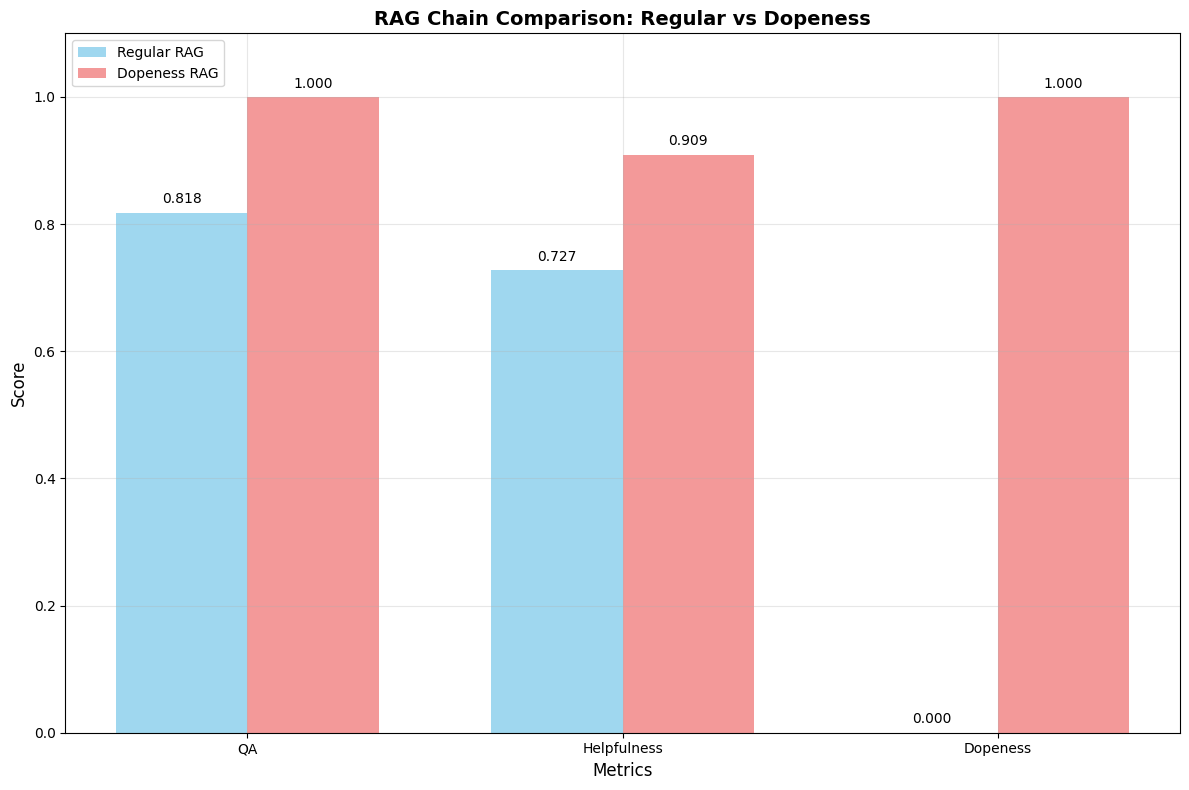

RAG Chain Comparison Results:
Metric          Regular RAG  Dopeness RAG Difference   Change  
----------------------------------------------------------------------
QA              0.818        1.000        0.182        ↑       
Helpfulness     0.727        0.909        0.182        ↑       
Dopeness        0.000        1.000        1.000        ↑       


In [54]:

# Convert to pandas DataFrames
regular_df = regular_eval.to_pandas()
dopeness_df = dopeness_eval.to_pandas()

# Calculate average scores for each metric
regular_scores = {
    'QA': regular_df['feedback.correctness'].mean(),
    'Helpfulness': regular_df['feedback.helpfulness'].mean(),
    'Dopeness': regular_df['feedback.dopeness'].mean()
}

dopeness_scores = {
    'QA': dopeness_df['feedback.correctness'].mean(),
    'Helpfulness': dopeness_df['feedback.helpfulness'].mean(),
    'Dopeness': dopeness_df['feedback.dopeness'].mean()
}

# Create comparison dataframe
comparison_data = {
    'Metric': ['QA', 'Helpfulness', 'Dopeness'],
    'Regular RAG': [regular_scores['QA'], regular_scores['Helpfulness'], regular_scores['Dopeness']],
    'Dopeness RAG': [dopeness_scores['QA'], dopeness_scores['Helpfulness'], dopeness_scores['Dopeness']]
}

df = pd.DataFrame(comparison_data)

# Create side-by-side bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Set up the bar positions
x = range(len(df['Metric']))
width = 0.35

# Create bars
bars1 = ax.bar([i - width/2 for i in x], df['Regular RAG'], width, label='Regular RAG', alpha=0.8, color='skyblue')
bars2 = ax.bar([i + width/2 for i in x], df['Dopeness RAG'], width, label='Dopeness RAG', alpha=0.8, color='lightcoral')

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

add_value_labels(bars1)
add_value_labels(bars2)

# Customize the chart
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('RAG Chain Comparison: Regular vs Dopeness', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Metric'])
ax.legend()
ax.grid(True, alpha=0.3)

# Set y-axis limits
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Print the comparison table
print("RAG Chain Comparison Results:")
print("=" * 60)
print(f"{'Metric':<15} {'Regular RAG':<12} {'Dopeness RAG':<12} {'Difference':<12} {'Change':<8}")
print("-" * 70)

for metric in ['QA', 'Helpfulness', 'Dopeness']:
    regular_score = regular_scores[metric]
    dopeness_score = dopeness_scores[metric]
    difference = dopeness_score - regular_score
    change = "↑" if difference > 0 else "↓" if difference < 0 else "="
    
    print(f"{metric:<15} {regular_score:<12.3f} {dopeness_score:<12.3f} {difference:<12.3f} {change:<8}")

print("=" * 70)